# *** Stroke Data Visualization Project ***
## Project Goal: Understanding the correlation between lifestyle and stroke incidents.

In [1]:
# import libraries what we needs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# laod the dataset stroke-data
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [3]:
df = pd.read_csv("healthcare-dataset-stroke-data.csv")

In [4]:
# first 5 records
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [5]:
# show information of columns (name of columns and count of null values and datatype)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [6]:
# Provide a statistical summary of the existing data
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [7]:
# show the number of diplicated value
df.duplicated().sum()

np.int64(0)

In [8]:
# show the shape (number of rows, number of columns)
df.shape

(5110, 12)

In [9]:
# the sum of isnull values to deal with
df.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

In [10]:
#Because smoking_state has many "Unknown" values, We will consider it as Null values

df["smoking_status"] = df["smoking_status"].replace("Unknown", np.nan)
print("Missing values before handling:")
print(df.isnull().sum())
missing_before = df.isnull().sum()

Missing values before handling:
id                      0
gender                  0
age                     0
hypertension            0
heart_disease           0
ever_married            0
work_type               0
Residence_type          0
avg_glucose_level       0
bmi                   201
smoking_status       1544
stroke                  0
dtype: int64


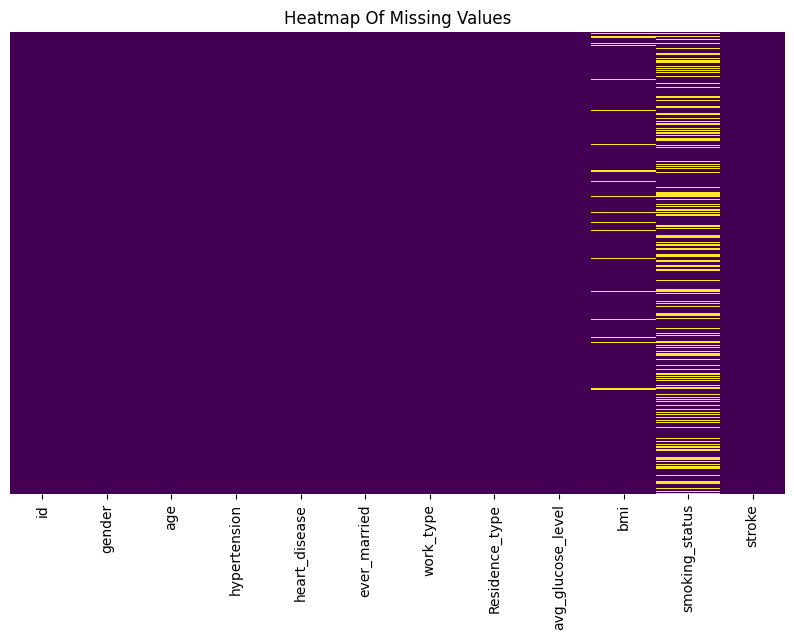

In [11]:
# heatmap to show missing values
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title("Heatmap Of Missing Values")
plt.show()

## Handling Missing Data:

1.   BMI
2.   smoking_status



In [12]:
'''To handle null values in BMI column,
I will use median values because it's more robust to extreme values compared with mean,
so it's more accurate to use it for data  🛠⚒⚒⚙'''

median_bmi = df["bmi"].median()
print(median_bmi)
df["bmi"] = df["bmi"].fillna(median_bmi)

28.1


In [13]:
#To handle null values in smoking_status, we will use mode, the most repititive value.
mode_smoking = df["smoking_status"].mode()[0]
df["smoking_status"] = df["smoking_status"].fillna(mode_smoking)

In [14]:
#To ensure that the data is completely free of missing values
print("Remaining Missing Values:")
print(df.isnull().sum())
missing_after = df.isnull().sum()

Remaining Missing Values:
id                   0
gender               0
age                  0
hypertension         0
heart_disease        0
ever_married         0
work_type            0
Residence_type       0
avg_glucose_level    0
bmi                  0
smoking_status       0
stroke               0
dtype: int64


# EDA ==>Exploratory Data Analysis

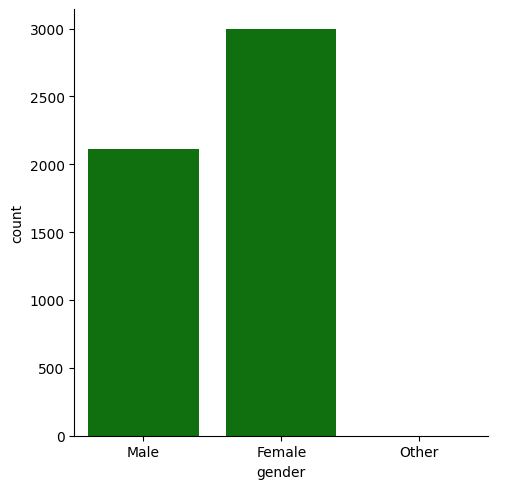

In [15]:
# number of male and female in the dataset
sns.catplot(x = 'gender', data = df, kind = 'count', color = 'green')  #the Female is grater than Male

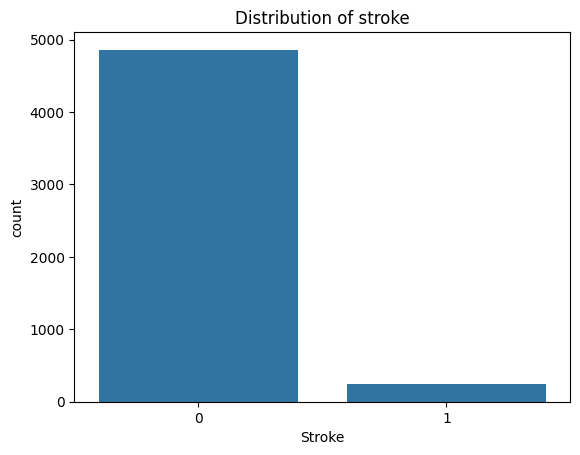

In [16]:
# count of stroke or not
sns.countplot(x = 'stroke', data = df)  # The number of people out of  the stroke is more than those injured
plt.title('Distribution of stroke')
plt.xlabel('Stroke')
plt.show()

In [17]:
#People with stroke by gender
df.groupby('gender')['stroke'].value_counts()

gender  stroke
Female  0         2853
        1          141
Male    0         2007
        1          108
Other   0            1
Name: count, dtype: int64

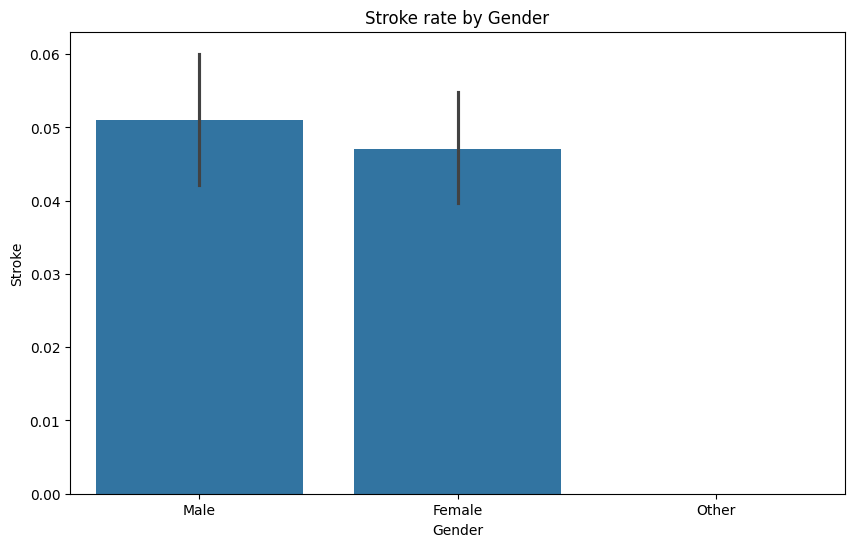

In [18]:
# male is more likely to infect
plt.figure(figsize=(10, 6))
sns.barplot(x = 'gender', y = 'stroke', data = df)
plt.title('Stroke rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Stroke')
plt.show()

In [19]:
df['smoking_status'].value_counts()

smoking_status
never smoked       3436
formerly smoked     885
smokes              789
Name: count, dtype: int64

In [20]:
#Groupby Number of smokers by gender
df.groupby('gender')['smoking_status'].value_counts()

gender  smoking_status 
Female  never smoked       2065
        formerly smoked     477
        smokes              452
Male    never smoked       1371
        formerly smoked     407
        smokes              337
Other   formerly smoked       1
Name: count, dtype: int64

<Axes: xlabel='smoking_status', ylabel='count'>

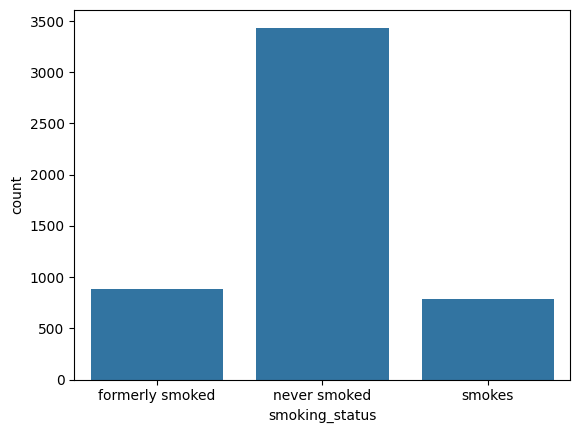

In [21]:
# count of smoking status
sns.countplot(x = 'smoking_status', data = df)

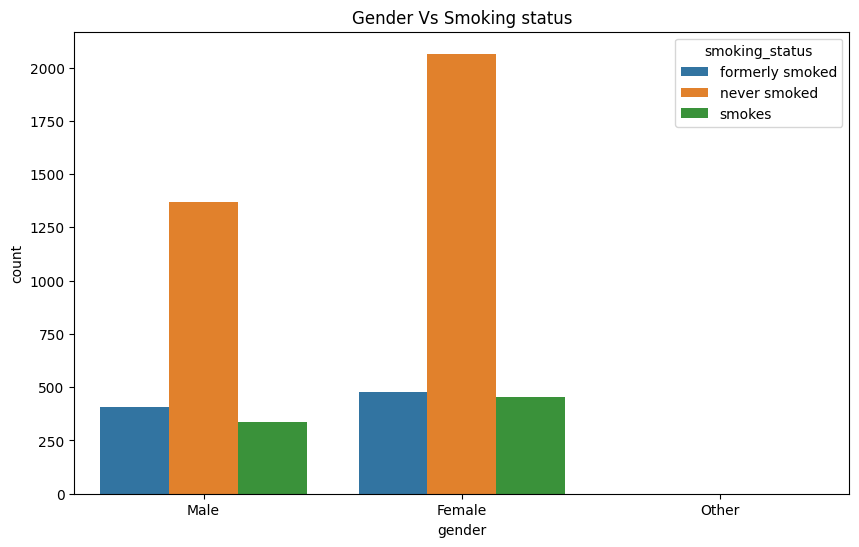

In [22]:
'''This plot compares smoking habits between genders.
It helps identify which smoking category is most dominant in each group,
revealing behavioral patterns related to health risks'''

plt.figure(figsize=(10, 6))
sns.countplot(x = df['gender'], hue = df['smoking_status'])
plt.title('Gender Vs Smoking status')
plt.show()

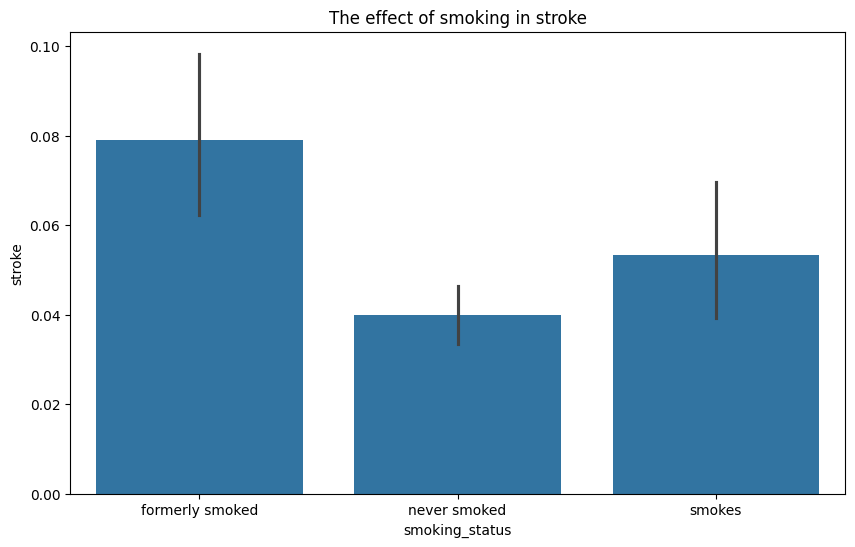

In [23]:
# The chart shows the increased rate of stroke among smokers (current and former) compared to those who have never smoked.
plt.figure(figsize=(10, 6))
sns.barplot(x = 'smoking_status', y = 'stroke', data = df)
plt.title('The effect of smoking in stroke')
plt.show()

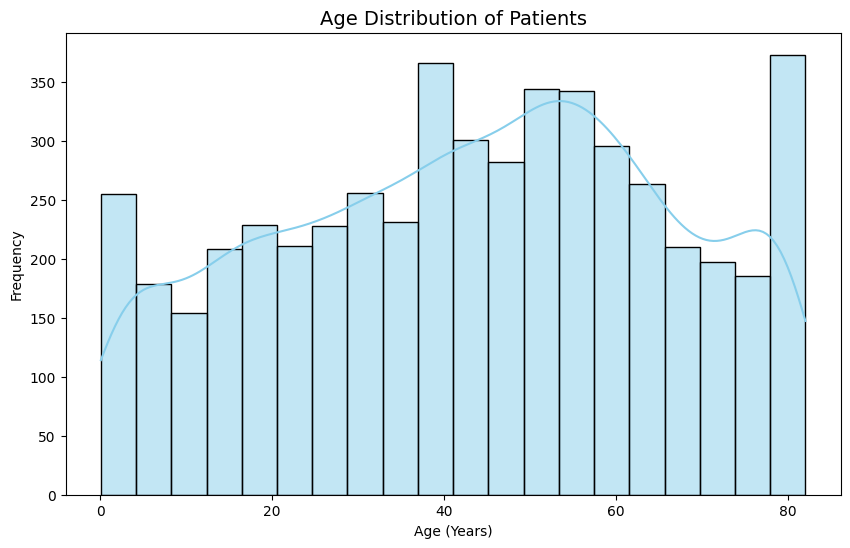

In [24]:
# Distribution of age groups
# Most patients in this dataset are middle-aged or elderly individuals
plt.figure(figsize=(10, 6))
sns.histplot(df['age'], kde=True, color='skyblue')

plt.title('Age Distribution of Patients', fontsize=14)
plt.xlabel('Age (Years)')
plt.ylabel('Frequency')
plt.show()


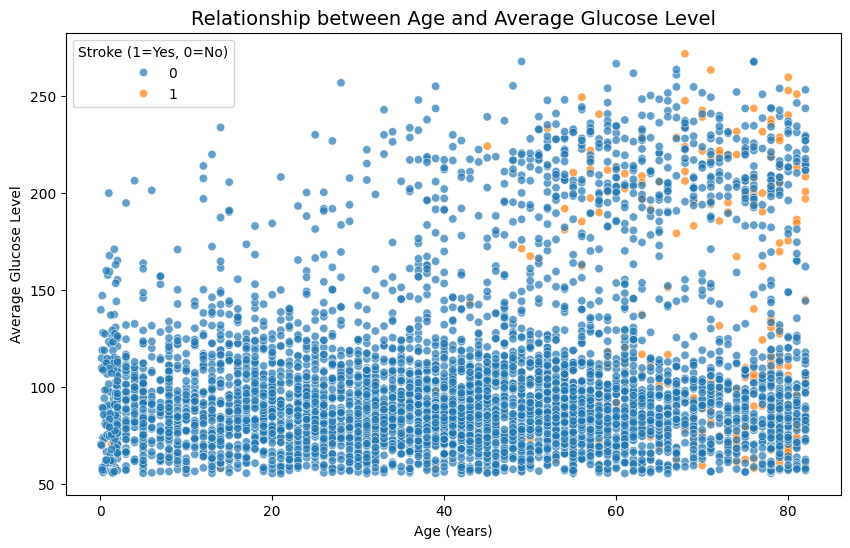

In [25]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='age', y='avg_glucose_level', hue='stroke', alpha=0.7)
plt.title('Relationship between Age and Average Glucose Level', fontsize=14)
plt.xlabel('Age (Years)')
plt.ylabel('Average Glucose Level')
plt.legend(title='Stroke (1=Yes, 0=No)')
plt.show()

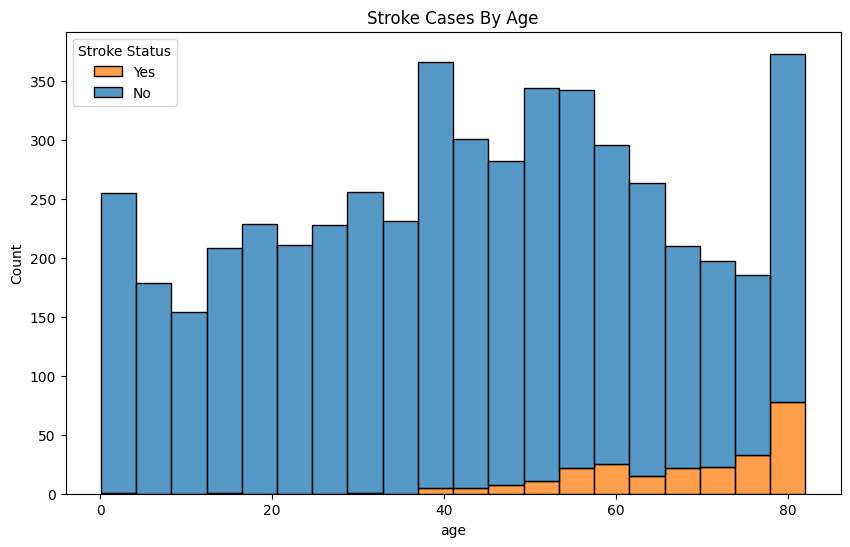

In [26]:
# The Strokes are concentrated from the age of forty and above
plt.figure(figsize=(10, 6))
sns.histplot(x = 'age', data = df, hue = 'stroke', multiple = 'stack')
plt.title('Stroke Cases By Age')
plt.legend(title = 'Stroke Status', labels = ['Yes', 'No'])
plt.show()

In [27]:
print(df.head())

      id  gender   age  hypertension  heart_disease ever_married  \
0   9046    Male  67.0             0              1          Yes   
1  51676  Female  61.0             0              0          Yes   
2  31112    Male  80.0             0              1          Yes   
3  60182  Female  49.0             0              0          Yes   
4   1665  Female  79.0             1              0          Yes   

       work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0        Private          Urban             228.69  36.6  formerly smoked   
1  Self-employed          Rural             202.21  28.1     never smoked   
2        Private          Rural             105.92  32.5     never smoked   
3        Private          Urban             171.23  34.4           smokes   
4  Self-employed          Rural             174.12  24.0     never smoked   

   stroke  
0       1  
1       1  
2       1  
3       1  
4       1  


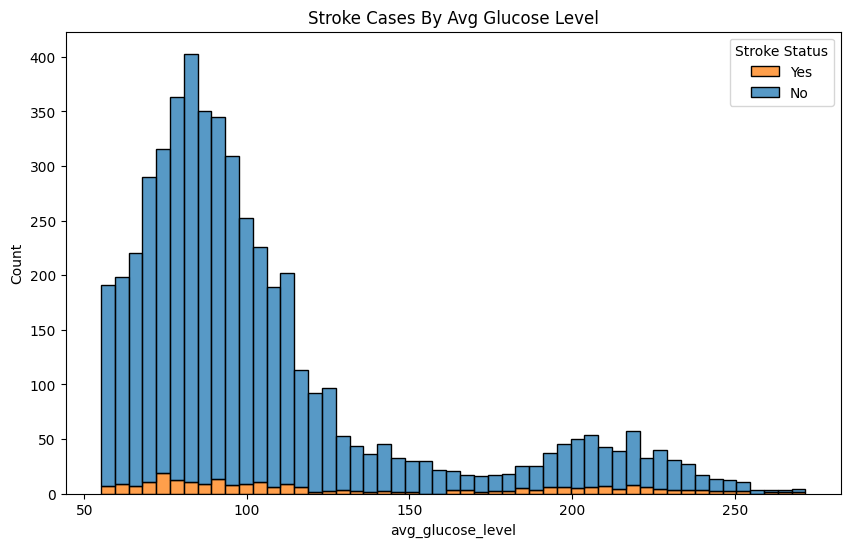

In [28]:
plt.figure(figsize=(10, 6))
sns.histplot(x = 'avg_glucose_level', data = df, hue = 'stroke', multiple = 'stack')
plt.title('Stroke Cases By Avg Glucose Level')
plt.legend(title = 'Stroke Status', labels = ['Yes', 'No'])
plt.show()

### Outlier Treatment:

### outliers of BMI

C:\Users\hp\AppData\Local\Temp\ipykernel_27068\3243299411.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='bmi',data=df, palette="pastel")


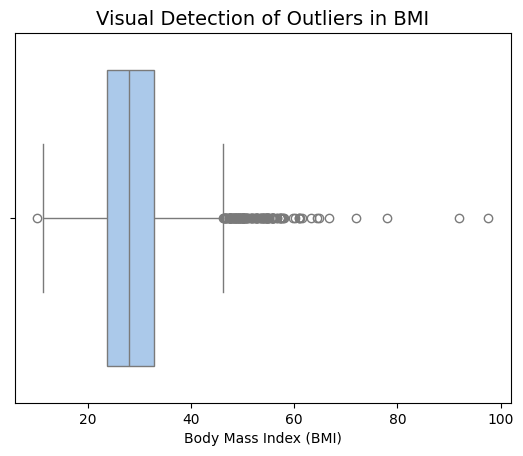

In [29]:
# Visualize the outlier values in the bmi before processing
sns.boxplot(x='bmi',data=df, palette="pastel")
plt.title("Visual Detection of Outliers in BMI", fontsize=14)
plt.xlabel("Body Mass Index (BMI)")
plt.show()

In [30]:
#Professional Outlier Handling for BMI
# Outlier Treatment (IQR Method)

# 1. Calculate Quartiles (Q1 & Q3)
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)

# 2. Calculate Interquartile Range (IQR)
IQR = Q3 - Q1

# 3. Define Upper and Lower Bounds [5, 6]
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 4. Filter the dataset to remove outliers
df_cleaned = df[(df['bmi'] >= lower_bound) & (df['bmi'] <= upper_bound)].copy()

print(f'Stats: Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}')
print(f'Bounds: [{lower_bound:.2f} to {upper_bound:.2f}]')


Stats: Q1 = 23.80, Q3 = 32.80, IQR = 9.00
Bounds: [10.30 to 46.30]


In [31]:
#show first 5 records after cleaning
df_cleaned.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,28.1,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


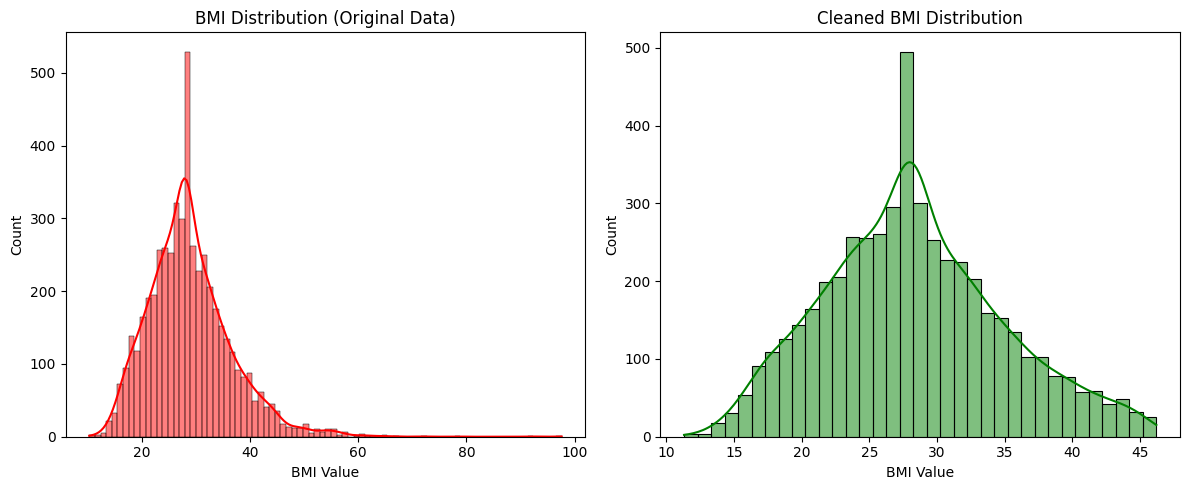

In [32]:
#To place the two charts side by side to observe the difference before and after handling the outlier values
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Figure 1: Original Data
sns.histplot(df['bmi'], kde=True, color='red', ax=axes[0])
axes[0].set_title("BMI Distribution (Original Data)")
axes[0].set_xlabel("BMI Value")

# Figure 2: Data after cleaning
sns.histplot(df_cleaned['bmi'], kde=True, color='green', ax=axes[1])
axes[1].set_title("Cleaned BMI Distribution")
axes[1].set_xlabel("BMI Value")

plt.tight_layout()  # To arrange the distances between them
plt.show()

### outliers of Avg_glucose_level

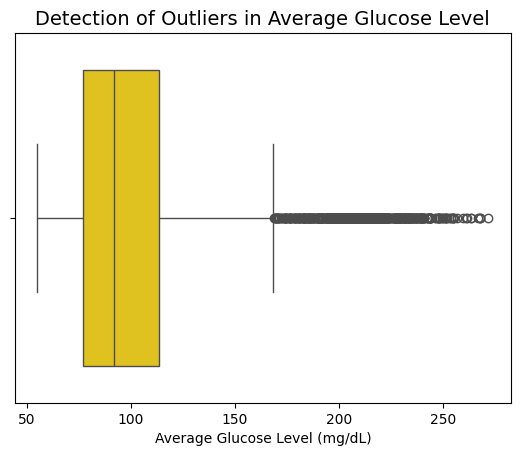

In [33]:
# Box plot for detecting outliers in blood sugar levels
sns.boxplot(x = df_cleaned['avg_glucose_level'], color='gold')
plt.title("Detection of Outliers in Average Glucose Level", fontsize=14)
plt.xlabel("Average Glucose Level (mg/dL)")
plt.show()


In [34]:
#  Professional Outlier Handling for Glucose ---

# 1. Calculating Quartiles and Interquartile Range for Blood Sugar Level
Q1_glu = df_cleaned['avg_glucose_level'].quantile(0.25)
Q3_glu = df_cleaned['avg_glucose_level'].quantile(0.75)
IQR_glu = Q3_glu - Q1_glu

# 2. Setting Safety Limits (The Bounds)
lower_glu = Q1_glu - 1.5 * IQR_glu
upper_glu = Q3_glu + 1.5 * IQR_glu

# 3. Final Filtering to Obtain Completely Clean
df_cleaned = df_cleaned[(df_cleaned['avg_glucose_level'] >= lower_glu) &
                            (df_cleaned['avg_glucose_level'] <= upper_glu)].copy()

# Display glucose statistical summary, calculated safe bounds for outlier detection, and final dataset size after cleaning
print(f"Stats for Glucose: Q1={Q1_glu:.2f}, Q3={Q3_glu:.2f}, IQR={IQR_glu:.2f}")
print(f"Safe Range for Glucose: [{lower_glu:.2f} to {upper_glu:.2f}]")
print(f"Final dataset shape: {df_cleaned.shape}")


Stats for Glucose: Q1=77.20, Q3=113.75, IQR=36.56
Safe Range for Glucose: [22.36 to 168.59]
Final dataset shape: (4390, 12)


In [35]:
#show first 5 records after cleaning
df_cleaned.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,28.1,never smoked,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,never smoked,1


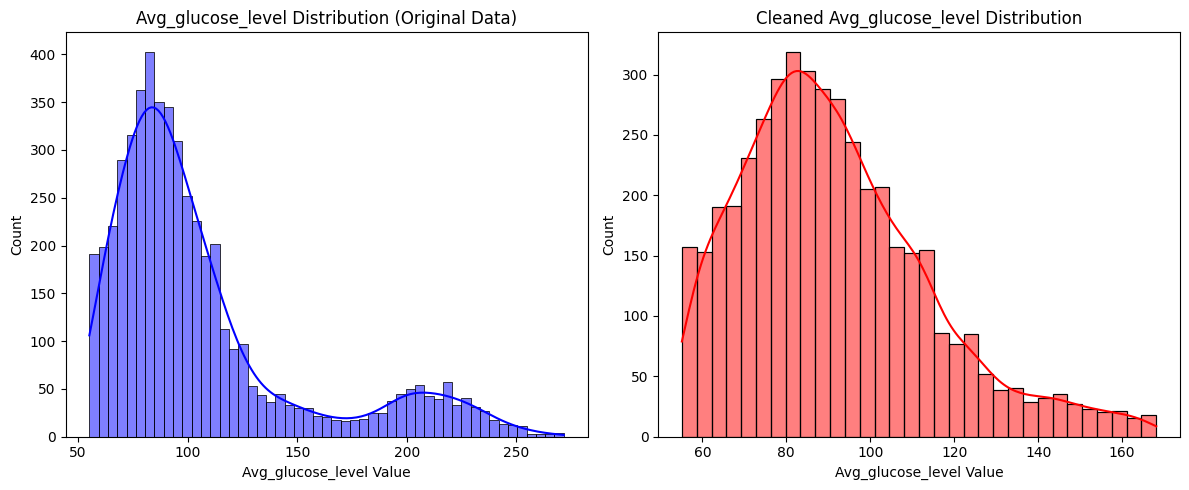

In [36]:
#To place the two charts side by side to observe the difference before and after handling the outlier values
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Figure 1: Original Data
sns.histplot(df['avg_glucose_level'], kde=True, color='blue', ax=axes[0])
axes[0].set_title("Avg_glucose_level Distribution (Original Data)")
axes[0].set_xlabel("Avg_glucose_level Value")

# Figure 2: Data after cleaning
sns.histplot(df_cleaned['avg_glucose_level'], kde=True, color='red', ax=axes[1])
axes[1].set_title("Cleaned Avg_glucose_level Distribution")
axes[1].set_xlabel("Avg_glucose_level Value")

plt.tight_layout()  # To arrange the distances between them
plt.show()

### outliers of Age

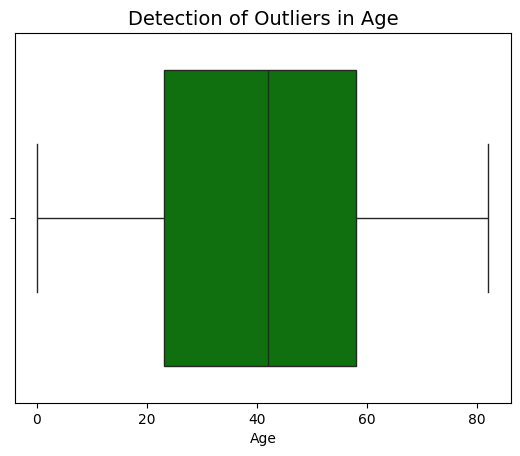

In [37]:
# Box plot for detecting extremists by age
sns.boxplot(x = df_cleaned['age'], color='green')
plt.title("Detection of Outliers in Age", fontsize=14)
plt.xlabel("Age")
plt.show()
#We notice that there are no outliers to handle

feature Engineering مثال أيضاً على :

In [38]:
# Define BMI classification ranges and labels, then create a categorical BMI column using pd.cut()
bins = [0, 18.5, 25, 30, 100]
labels = ['Underweight', 'Healthy weight', 'Overweight', 'Obese']
# Create BMI category column
df_cleaned['bmi_category'] = pd.cut(df_cleaned['bmi'],bins=bins,labels=labels)

In [39]:
print(df_cleaned['bmi_category'].value_counts())

bmi_category
Obese             1449
Overweight        1399
Healthy weight    1199
Underweight        343
Name: count, dtype: int64


In [40]:
# حساب مجموع عوامل الخطر الموجودة
df['risk_factors_sum'] = (df['hypertension'] + df['heart_disease'] + (df['age'] > 65).astype(int) + (df['bmi'] > 30).astype(int) +
                          (df['avg_glucose_level'] > 200).astype(int))


In [41]:
df_cleaned.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_category
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Obese
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1,Overweight
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1,Healthy weight
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,28.1,never smoked,1,Overweight
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,never smoked,1,Healthy weight


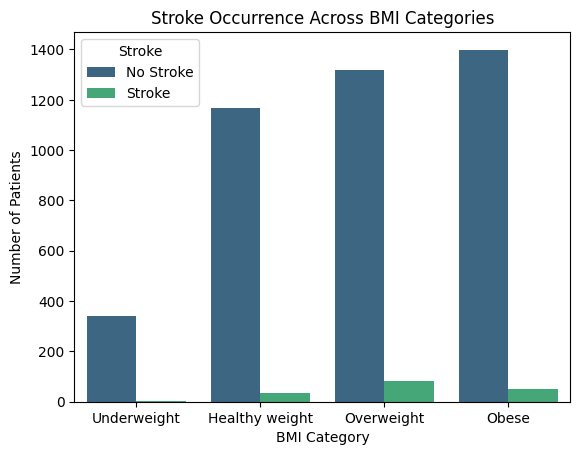

In [42]:
# Visualize the relationship between BMI categories and stroke occurrence using a count plot
sns.countplot(x='bmi_category', data=df_cleaned, hue='stroke', palette='viridis')
plt.title("Stroke Occurrence Across BMI Categories")
plt.xlabel("BMI Category")
plt.ylabel("Number of Patients")
plt.legend(title='Stroke', labels=['No Stroke', 'Stroke'])
plt.show()


In [43]:
#I grouped ages into categories to analyze age distribution in the dataset.
age_bins = [0, 18, 35, 60, float('inf')]
age_labels = ['Child/Teen', 'Young Adult', 'Adult', 'Senior']
df_cleaned['age_category'] = pd.cut( df_cleaned['age'],
                                     bins=age_bins,
                                     labels=age_labels)

print(df_cleaned['age_category'].value_counts())


age_category
Adult          1603
Senior          968
Young Adult     927
Child/Teen      892
Name: count, dtype: int64


In [44]:
df_cleaned.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_category,age_category
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,Obese,Senior
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1,Overweight,Senior
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1,Healthy weight,Senior
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,28.1,never smoked,1,Overweight,Adult
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,never smoked,1,Healthy weight,Senior


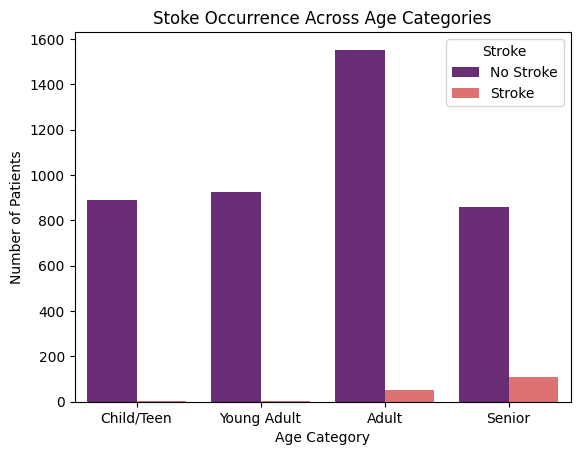

In [45]:
# Visualize the relationship between BMI categories and stroke occurrence using a count plot
sns.countplot(x='age_category', data=df_cleaned, hue='stroke', palette='magma')
plt.title("Stoke Occurrence Across Age Categories")
plt.xlabel("Age Category")
plt.ylabel("Number of Patients")
plt.legend(title='Stroke', labels=['No Stroke', 'Stroke'])
plt.show()

### Feature Transformation:

In [46]:
# Converting numeric columns to decimal
numeric_cols = ['age', 'avg_glucose_level', 'bmi']
for col in numeric_cols:
    df_cleaned[col] = df_cleaned[col].astype(float)

In [47]:
# Converting 'ever_married' (Yes/No) to (1/0)
df_cleaned['ever_married'] = df_cleaned['ever_married'].map({'Yes': 1, 'No': 0})

In [48]:
df_cleaned.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_category,age_category
2,31112,Male,80.0,0,1,1,Private,Rural,105.92,32.5,never smoked,1,Obese,Senior
6,53882,Male,74.0,1,1,1,Private,Rural,70.09,27.4,never smoked,1,Overweight,Senior
7,10434,Female,69.0,0,0,0,Private,Urban,94.39,22.8,never smoked,1,Healthy weight,Senior
8,27419,Female,59.0,0,0,1,Private,Rural,76.15,28.1,never smoked,1,Overweight,Adult
9,60491,Female,78.0,0,0,1,Private,Urban,58.57,24.2,never smoked,1,Healthy weight,Senior


In [49]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4390 entries, 2 to 5109
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   id                 4390 non-null   int64   
 1   gender             4390 non-null   object  
 2   age                4390 non-null   float64 
 3   hypertension       4390 non-null   int64   
 4   heart_disease      4390 non-null   int64   
 5   ever_married       4390 non-null   int64   
 6   work_type          4390 non-null   object  
 7   Residence_type     4390 non-null   object  
 8   avg_glucose_level  4390 non-null   float64 
 9   bmi                4390 non-null   float64 
 10  smoking_status     4390 non-null   object  
 11  stroke             4390 non-null   int64   
 12  bmi_category       4390 non-null   category
 13  age_category       4390 non-null   category
dtypes: category(2), float64(3), int64(5), object(4)
memory usage: 454.8+ KB


### Digital data normalization

In [50]:
# 1. Identify the numerical columns to be normalized
cols_to_normalize = ['age', 'avg_glucose_level', 'bmi']

# 2. Apply the normalization equation manually: (value of the element - smallest value) / (largest value - smallest value)
for col in cols_to_normalize:
    min_val = df_cleaned[col].min()
    max_val = df_cleaned[col].max()
    df_cleaned[col] = (df_cleaned[col] - min_val) / (max_val - min_val)

# 3. Make sure that all values are between 0 and 1
print(df_cleaned[cols_to_normalize].describe())

               age  avg_glucose_level          bmi
count  4390.000000        4390.000000  4390.000000
mean      0.498136           0.321503     0.472410
std       0.275132           0.200257     0.187965
min       0.000000           0.000000     0.000000
25%       0.279785           0.176524     0.340974
50%       0.511719           0.291250     0.468481
75%       0.707031           0.432584     0.590258
max       1.000000           1.000000     1.000000


In [51]:
# Save the data in a new file named 'Cleaned Data' as required
df_cleaned.to_csv('Cleaned Data.csv', index=False)

In [52]:
df_cleaned

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,bmi_category,age_category
2,31112,Male,0.975586,0,1,1,Private,Rural,0.449438,0.607450,never smoked,1,Obese,Senior
6,53882,Male,0.902344,1,1,1,Private,Rural,0.132443,0.461318,never smoked,1,Overweight,Senior
7,10434,Female,0.841309,0,0,0,Private,Urban,0.347430,0.329513,never smoked,1,Healthy weight,Senior
8,27419,Female,0.719238,0,0,1,Private,Rural,0.186057,0.481375,never smoked,1,Overweight,Adult
9,60491,Female,0.951172,0,0,1,Private,Urban,0.030523,0.369628,never smoked,1,Healthy weight,Senior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,0.975586,1,0,1,Private,Urban,0.253296,0.481375,never smoked,0,Overweight,Senior
5106,44873,Female,0.987793,0,0,1,Self-employed,Urban,0.620012,0.822350,never smoked,0,Obese,Senior
5107,19723,Female,0.426270,0,0,1,Self-employed,Rural,0.246572,0.553009,never smoked,0,Obese,Young Adult
5108,37544,Male,0.621582,0,0,1,Private,Rural,0.983544,0.409742,formerly smoked,0,Overweight,Adult
